In [6]:
# =======================
# 1. Bibliotēku instalēšana un importēšana
# =======================
!pip install gensim stanza --quiet

import zipfile
import re
from collections import defaultdict
import stanza
from gensim.models import Word2Vec
from google.colab import files

# =======================
# 2. Stanza inicializācija
# =======================
print("Lejupielādē un inicializē Stanza latviešu valodas modeli...")
stanza.download('lv', processors='tokenize,pos,lemma')
# Izmantojam GPU, ja tas ir pieejams (Colab vidē ieteicams ieslēgt Hardware Accelerator: GPU)
nlp = stanza.Pipeline('lv', processors='tokenize,pos,lemma', use_gpu=True, logging_level='WARN')

# =======================
# 3. ZIP faila ielāde
# =======================
print("\nLūdzu, augšupielādējiet ZIP failu ar skrejlapām:")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# =======================
# 4. Palīgfunkcijas tekstoloģiskajai apstrādei
# =======================
def extract_text_block(raw: str) -> str:
    """Ekstrahē galveno tekstu, atdalot to no metadatiem."""
    lines = raw.splitlines()
    text_start_idx = None

    for i, line in enumerate(lines):
        if line.strip().lower().startswith("text"):
            text_start_idx = i + 1
            break

    if text_start_idx is None:
        text_start_idx = 0
        for i, line in enumerate(lines):
            if re.match(r"^\s*\w+\s*:", line):
                continue
            else:
                text_start_idx = i
                break

    return "\n".join(lines[text_start_idx:])

def extract_year(raw: str) -> str:
    """
    Ekstrahē izdošanas gadu no metadatiem.
    Optimizēta regulārā izteiksme atrod pirmo četrciparu virkni (gadu)
    rindā, kas sākas ar 'date:', ignorējot iekavas un citus simbolus.
    """
    match = re.search(r"(?i)^date:.*?(\d{4})", raw, flags=re.MULTILINE)
    if match:
        return match.group(1)
    return "Unknown"

def lemmatize_text(text: str) -> list:
    """
    Veic teksta lematizāciju izmantojot Stanza.
    Izfiltrē pieturzīmes (PUNCT), simbolus (SYM) un ciparus (NUM).
    """
    # 1. Specifisko vēsturisko saīsinājumu normalizācija pirms lematizācijas
    text = re.sub(r"s\.\-d\.?", "sociāldemokrāti", text, flags=re.IGNORECASE)

    # 2. Stanza apstrāde
    doc = nlp(text)

    lemmas = []
    for sentence in doc.sentences:
        for word in sentence.words:
            # Filtrējam nevēlamos vārdšķiru tegu (UPOS) tipus
            if word.upos not in ['PUNCT', 'SYM', 'NUM'] and word.lemma:
                lemmas.append(word.lemma.lower())

    return lemmas

# =======================
# 5. Datu izgūšana un lematizācija pa gadiem
# =======================
texts_by_year = defaultdict(list)
leaflet_count = 0

print("\nUzsākta tekstu izgūšana un lematizācija (tas var aizņemt laiku)...")
with zipfile.ZipFile(zip_filename, "r") as zf:
    txt_names = [n for n in zf.namelist() if n.endswith(".txt")]
    total_files = len(txt_names)
    print(f"Kopumā atrasti {total_files} .txt faili arhīvā.")

    for index, name in enumerate(txt_names, start=1):
        raw_bytes = zf.read(name)
        try:
            raw = raw_bytes.decode("utf-8")
        except UnicodeDecodeError:
            raw = raw_bytes.decode("utf-8", errors="ignore")

        year = extract_year(raw)
        if year != "Unknown":
            text_body = extract_text_block(raw)

            # Pielietojam Stanza lematizāciju
            lemmatized_tokens = lemmatize_text(text_body)

            if lemmatized_tokens:
                texts_by_year[year].append(lemmatized_tokens)
                leaflet_count += 1

        # Progresa atskaite katriem 10 failiem vai apstrādes beigās
        if index % 10 == 0 or index == total_files:
            print(f"Progresa atskaite: apstrādāti {index} no {total_files} failiem (veiksmīgi lematizētas {leaflet_count} skrejlapas).")

print(f"\nApstrāde pabeigta. Kopā klasificētas {leaflet_count} skrejlapas ar identificējamiem gadiem.")

# =======================
# 6. Word2Vec modeļu apmācība un analīze
# =======================
models_by_year = {}

print("\nApmāca Word2Vec modeļus katram gadam...")
for year in sorted(texts_by_year.keys()):
    corpus = texts_by_year[year]
    model = Word2Vec(
        sentences=corpus,
        vector_size=50,
        window=5,
        min_count=1,
        sg=1,
        workers=4,
        epochs=15  # Palielināts epohu skaits labākai konverģencei ar lematizētiem datiem
    )
    models_by_year[year] = model

# Analīzes piemērs
pairs_to_check = [("sociāldemokrāts", "fašists"), ("ulmanis", "diktatūra")]

print("\n" + "="*50)
print("DIHRONISKĀ KOSINUSA LĪDZĪBA (Lematizēti dati)")
print("="*50)

for w1, w2 in pairs_to_check:
    print(f"\n--- Pāris: '{w1}' ↔ '{w2}' ---")
    for year in sorted(models_by_year.keys()):
        model = models_by_year[year]
        if w1 in model.wv.key_to_index and w2 in model.wv.key_to_index:
            similarity = model.wv.similarity(w1, w2)
            print(f"Gads {year}: {similarity:.3f}")
        else:
            missing = [w for w in (w1, w2) if w not in model.wv.key_to_index]
            print(f"Gads {year}: Nav datu (trūkst: {', '.join(missing)})")

Lejupielādē un inicializē Stanza latviešu valodas modeli...



Lūdzu, augšupielādējiet ZIP failu ar skrejlapām:


Saving LCLC_1934-1940_only_unique_text_leaflets.zip to LCLC_1934-1940_only_unique_text_leaflets (5).zip

Uzsākta tekstu izgūšana un lematizācija (tas var aizņemt laiku)...
Kopumā atrasti 251 .txt faili arhīvā.
Progresa atskaite: apstrādāti 10 no 251 failiem (veiksmīgi lematizētas 10 skrejlapas).
Progresa atskaite: apstrādāti 20 no 251 failiem (veiksmīgi lematizētas 20 skrejlapas).
Progresa atskaite: apstrādāti 30 no 251 failiem (veiksmīgi lematizētas 30 skrejlapas).
Progresa atskaite: apstrādāti 40 no 251 failiem (veiksmīgi lematizētas 40 skrejlapas).
Progresa atskaite: apstrādāti 50 no 251 failiem (veiksmīgi lematizētas 50 skrejlapas).
Progresa atskaite: apstrādāti 60 no 251 failiem (veiksmīgi lematizētas 60 skrejlapas).
Progresa atskaite: apstrādāti 70 no 251 failiem (veiksmīgi lematizētas 70 skrejlapas).
Progresa atskaite: apstrādāti 80 no 251 failiem (veiksmīgi lematizētas 80 skrejlapas).
Progresa atskaite: apstrādāti 90 no 251 failiem (veiksmīgi lematizētas 90 skrejlapas).
Progres

Lejupielādē un inicializē Stanza latviešu valodas modeli...



Lūdzu, augšupielādējiet ZIP failu ar skrejlapām:


Saving LCLC_1934-1940_only_unique_text_leaflets.zip to LCLC_1934-1940_only_unique_text_leaflets (7).zip

Uzsākta tekstu izgūšana un lematizācija (tas var aizņemt laiku)...
Kopumā atrasti 251 .txt faili arhīvā.
Progresa atskaite: apstrādāti 10 no 251 failiem (veiksmīgi lematizētas 10 skrejlapas).
Progresa atskaite: apstrādāti 20 no 251 failiem (veiksmīgi lematizētas 20 skrejlapas).
Progresa atskaite: apstrādāti 30 no 251 failiem (veiksmīgi lematizētas 30 skrejlapas).
Progresa atskaite: apstrādāti 40 no 251 failiem (veiksmīgi lematizētas 40 skrejlapas).
Progresa atskaite: apstrādāti 50 no 251 failiem (veiksmīgi lematizētas 50 skrejlapas).
Progresa atskaite: apstrādāti 60 no 251 failiem (veiksmīgi lematizētas 60 skrejlapas).
Progresa atskaite: apstrādāti 70 no 251 failiem (veiksmīgi lematizētas 70 skrejlapas).
Progresa atskaite: apstrādāti 80 no 251 failiem (veiksmīgi lematizētas 80 skrejlapas).
Progresa atskaite: apstrādāti 90 no 251 failiem (veiksmīgi lematizētas 90 skrejlapas).
Progres

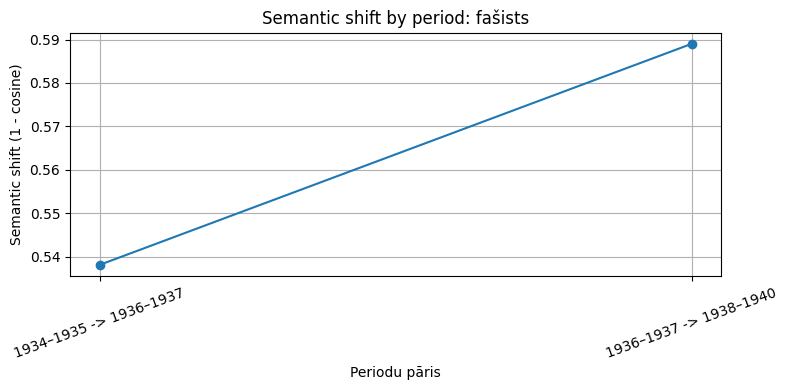

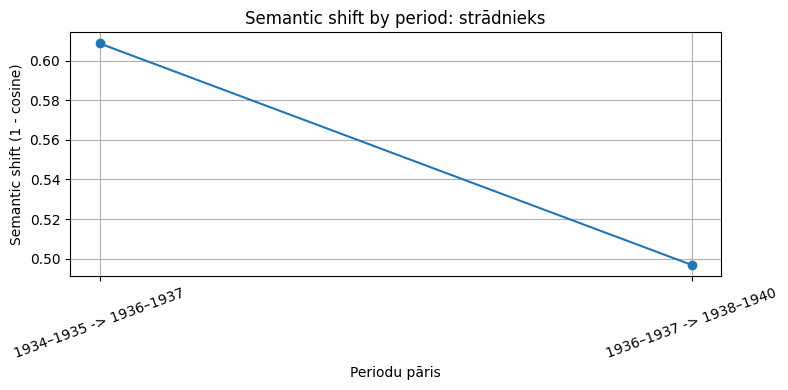

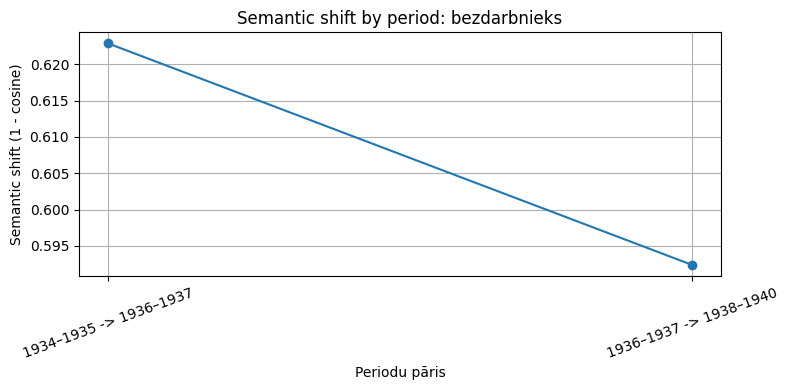

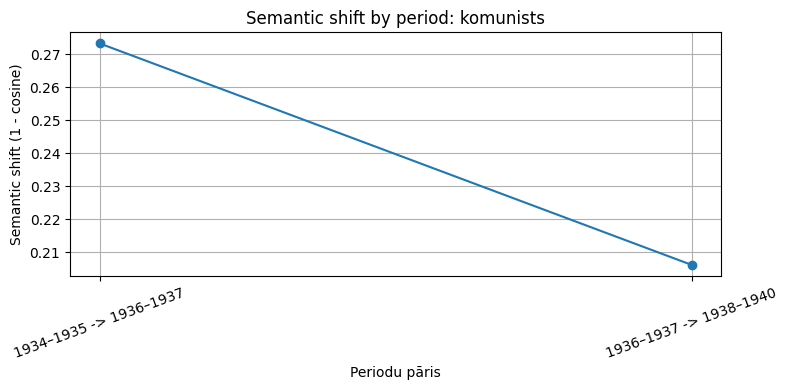

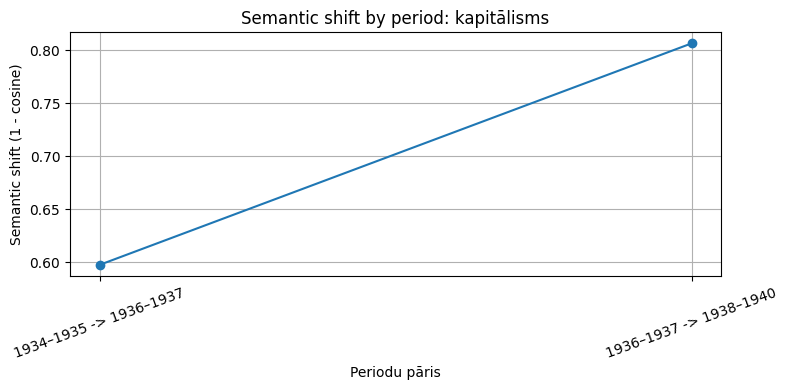

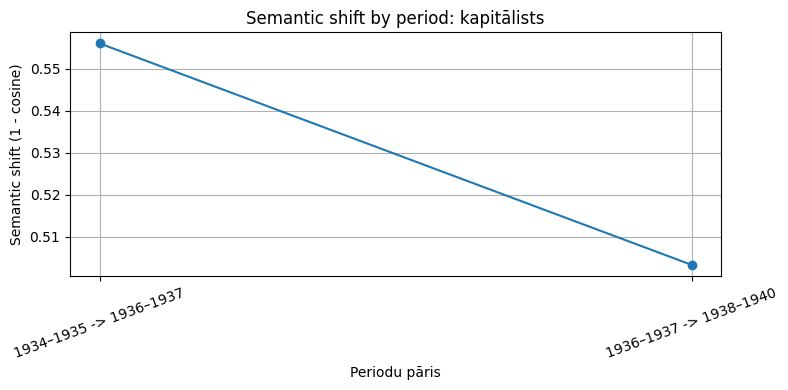

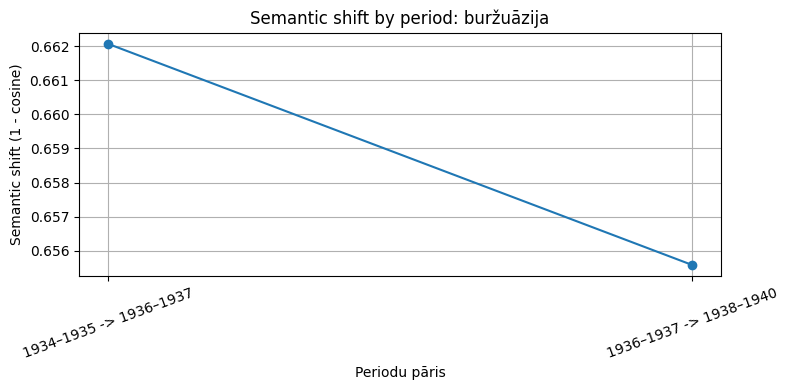

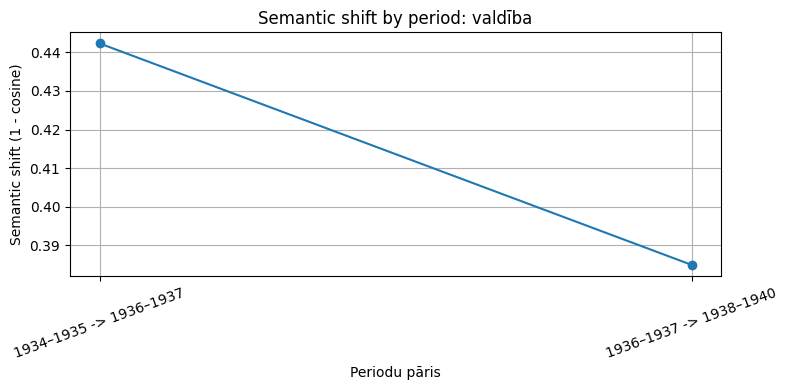

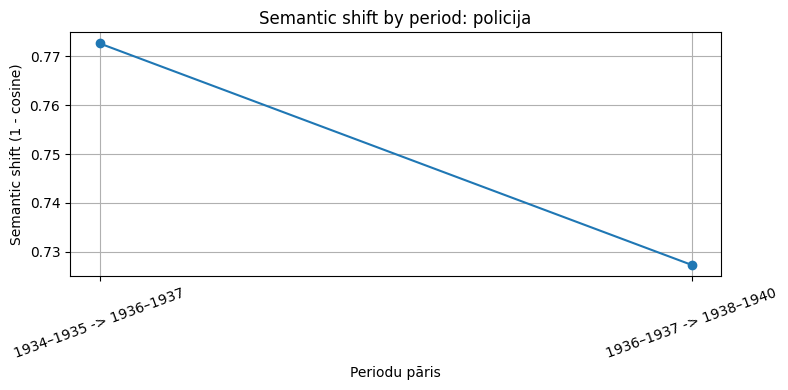

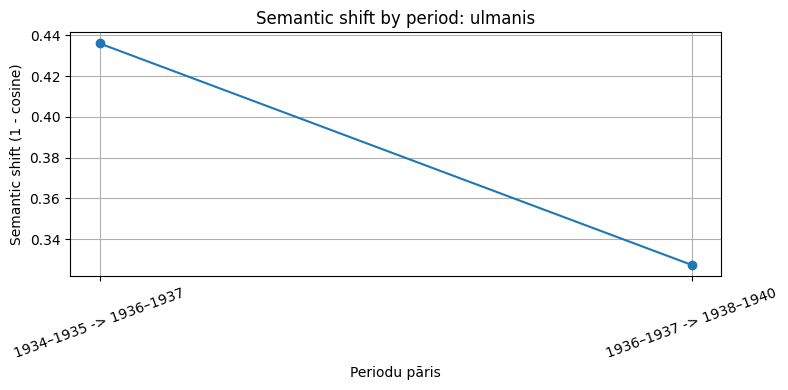

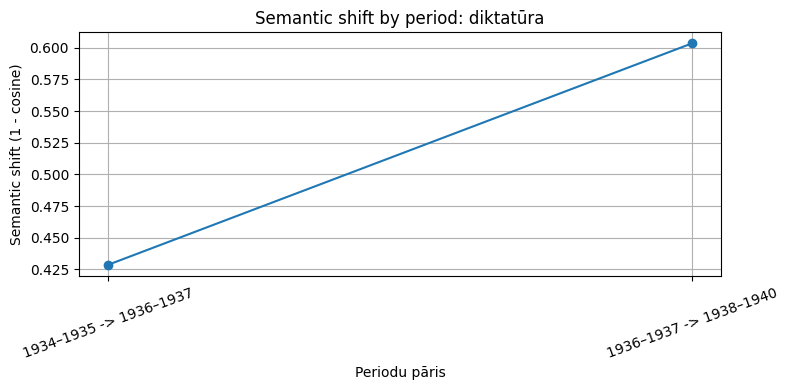

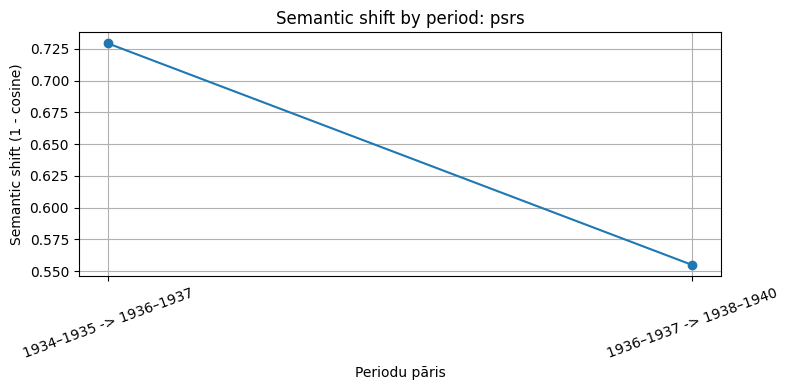

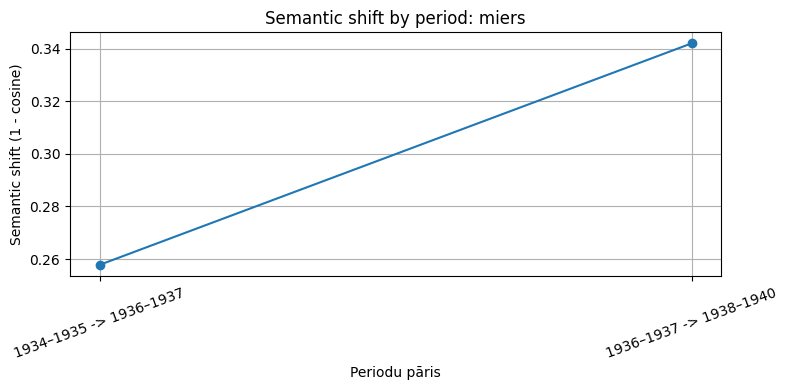

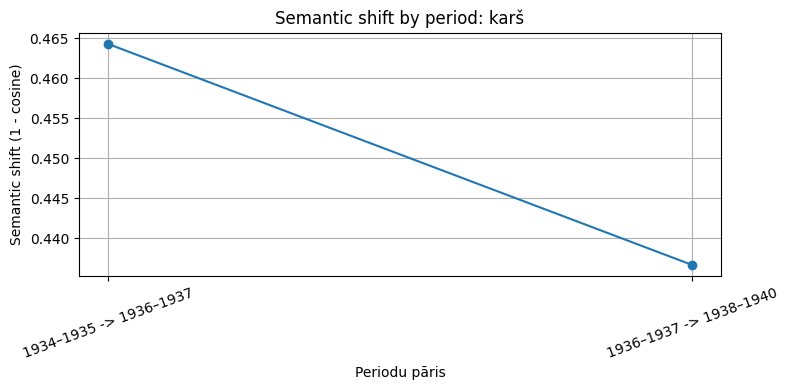

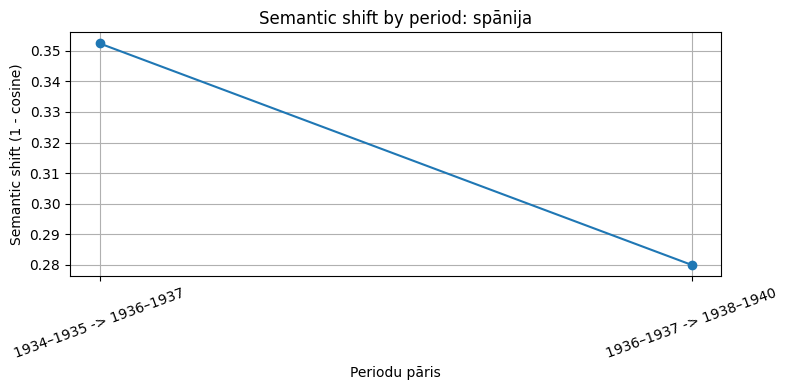

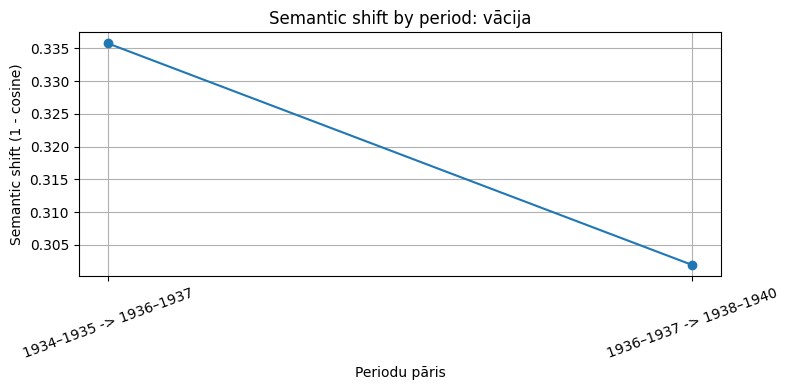


TOP KAIMIŅI PA PERIODIEM

--- sociāldemokrāts ---
1934–1935: līderis (0.83), kristīgs (0.56), nodevīgs (0.55), uzmest (0.54), reformistisks (0.53), karst (0.53), solīties (0.51), bankrotēt (0.50)
1936–1937: nav vārdnīcā
1938–1940: nav vārdnīcā

--- fašists ---
1934–1935: patvarība (0.55), pasākums (0.55), teroristisks (0.54), ulmanis (0.52), saziņa (0.52), pērkoņkrusts (0.50), spīts (0.50), maskēt (0.50)
1936–1937: krāpšana (0.55), dziesma (0.55), padoties (0.55), pār (0.55), bende (0.55), varmāka (0.54), monarhistisks (0.54), mola (0.54)
1938–1940: iekarotājs (0.62), piekritējs (0.58), vaļa (0.57), iebrukums (0.56), izšķirties (0.56), stiprs (0.56), despotija (0.55), junkurs (0.55)

--- strādnieks ---
1934–1935: un (0.60), kalpotājs (0.51), maiznieks (0.50), turpināšana (0.50), darbs (0.49), lamāt (0.49), sportists (0.49), terorizēt (0.49)
1936–1937: budži (0.57), inteliģents (0.55), ilūzija (0.55), cerēt (0.54), aktivitāte (0.54), uzlabojums (0.53), kalpotājs (0.53), nodarbināt (0.5

In [8]:
# =======================
# 1. Install libraries
# =======================
!pip install gensim stanza scipy pandas matplotlib --quiet

# =======================
# 2. Imports
# =======================
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from google.colab import files
from gensim.models import Word2Vec
from scipy.linalg import orthogonal_procrustes
import stanza

# =======================
# 3. Stanza initialization
# =======================
print("Lejupielādē un inicializē Stanza latviešu valodas modeli...")
stanza.download('lv', processors='tokenize,pos,lemma')

nlp = stanza.Pipeline(
    'lv',
    processors='tokenize,pos,lemma',
    use_gpu=True,
    logging_level='WARN'
)

# =======================
# 4. Upload ZIP
# =======================
print("\nLūdzu, augšupielādējiet ZIP failu ar skrejlapām:")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# =======================
# 5. Helper functions
# =======================
def extract_text_block(raw: str) -> str:
    lines = raw.splitlines()
    text_start_idx = None

    for i, line in enumerate(lines):
        if line.strip().lower().startswith("text"):
            text_start_idx = i + 1
            break

    if text_start_idx is None:
        text_start_idx = 0
        for i, line in enumerate(lines):
            if re.match(r"^\s*\w+\s*:", line):
                continue
            else:
                text_start_idx = i
                break

    return "\n".join(lines[text_start_idx:]).strip()


def extract_year(raw: str, fallback_name: str = ""):
    m = re.search(r"(?im)^\s*date\s*:\s*(.+)$", raw)
    if m:
        date_value = m.group(1).strip()
        y = re.search(r"(19\d{2}|20\d{2})", date_value)
        if y:
            return int(y.group(1))

    m2 = re.search(r"(?im)^\s*file_name\s*:\s*(.+)$", raw)
    if m2:
        file_value = m2.group(1).strip()
        y2 = re.search(r"(19\d{2}|20\d{2})", file_value)
        if y2:
            return int(y2.group(1))

    if fallback_name:
        y3 = re.search(r"(19\d{2}|20\d{2})", fallback_name)
        if y3:
            return int(y3.group(1))

    return None


def year_to_period(year: int):
    if year in [1934, 1935]:
        return "1934–1935"
    elif year in [1936, 1937]:
        return "1936–1937"
    elif year in [1938, 1939, 1940]:
        return "1938–1940"
    return None


def normalize_lemma(lemma: str) -> str:
    lemma = lemma.lower().strip()

    if lemma.startswith("sociāldemokr"):
        return "sociāldemokrāts"
    if lemma.startswith("fašist"):
        return "fašists"
    if lemma.startswith("komunist"):
        return "komunists"
    if lemma.startswith("strādniek"):
        return "strādnieks"
    if lemma.startswith("bezdarbniek"):
        return "bezdarbnieks"
    if lemma.startswith("kapitālist"):
        return "kapitālists"
    if lemma.startswith("buržuāz"):
        return "buržuāzija"

    return lemma


def lemmatize_text(text: str):
    text = re.sub(r"s\.\-d\.?", " sociāldemokrāti ", text, flags=re.IGNORECASE)
    text = re.sub(r"1\.\s*maijs", " pirmais_maijs ", text, flags=re.IGNORECASE)
    text = re.sub(r"7\.\s*novembris", " septītais_novembris ", text, flags=re.IGNORECASE)
    text = re.sub(r"padomju latvija", " padomju_latvija ", text, flags=re.IGNORECASE)
    text = re.sub(r"politiskā pārvalde", " politiskā_pārvalde ", text, flags=re.IGNORECASE)

    doc = nlp(text)

    lemmas = []
    for sentence in doc.sentences:
        for word in sentence.words:
            if word.upos not in ['PUNCT', 'SYM', 'NUM'] and word.lemma:
                lemma = normalize_lemma(word.lemma)

                if re.fullmatch(r"[a-zāčēģīķļņšūž_]+", lemma):
                    lemmas.append(lemma)

    return lemmas


def cosine(v1, v2):
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return np.nan
    return float(np.dot(v1, v2) / denom)


def get_common_vocab(model1, model2, min_intersection=50):
    vocab1 = set(model1.wv.key_to_index.keys())
    vocab2 = set(model2.wv.key_to_index.keys())
    common = list(vocab1 & vocab2)

    if len(common) < min_intersection:
        return common

    common_sorted = sorted(
        common,
        key=lambda w: model1.wv.get_vecattr(w, "count") + model2.wv.get_vecattr(w, "count"),
        reverse=True
    )
    return common_sorted


def build_anchor_matrices(model1, model2, anchor_words):
    X = np.vstack([model1.wv[w] for w in anchor_words])
    Y = np.vstack([model2.wv[w] for w in anchor_words])
    return X, Y


def align_models(base_model, other_model, anchor_words):
    X, Y = build_anchor_matrices(base_model, other_model, anchor_words)

    X_mean = X.mean(axis=0, keepdims=True)
    Y_mean = Y.mean(axis=0, keepdims=True)

    Xc = X - X_mean
    Yc = Y - Y_mean

    R, _ = orthogonal_procrustes(Yc, Xc)
    return R


def aligned_vector(model, word, R=None):
    vec = model.wv[word]
    if R is not None:
        vec = vec @ R
    return vec


def get_top_neighbors(model, word, topn=10):
    if word not in model.wv.key_to_index:
        return []
    return model.wv.most_similar(word, topn=topn)

# =======================
# 6. Read and lemmatize texts by period
# =======================
texts_by_period = defaultdict(list)
leaflet_count = 0
failed_files = []

print("\nUzsākta tekstu izgūšana un lematizācija (tas var aizņemt laiku)...")

with zipfile.ZipFile(zip_filename, "r") as zf:
    txt_names = [n for n in zf.namelist() if n.endswith(".txt")]
    total_files = len(txt_names)
    print(f"Kopumā atrasti {total_files} .txt faili arhīvā.")

    for index, name in enumerate(txt_names, start=1):
        raw_bytes = zf.read(name)
        try:
            raw = raw_bytes.decode("utf-8")
        except UnicodeDecodeError:
            raw = raw_bytes.decode("utf-8", errors="ignore")

        year = extract_year(raw, fallback_name=name)
        if year is None:
            failed_files.append((name, "year_not_found"))
            continue

        period = year_to_period(year)
        if period is None:
            failed_files.append((name, f"year_out_of_range_{year}"))
            continue

        text_body = extract_text_block(raw)
        if not text_body:
            failed_files.append((name, "empty_text_block"))
            continue

        lemmas = lemmatize_text(text_body)
        if len(lemmas) == 0:
            failed_files.append((name, "empty_after_lemmatization"))
            continue

        texts_by_period[period].append(lemmas)
        leaflet_count += 1

        if index % 10 == 0 or index == total_files:
            print(f"Progresa atskaite: apstrādāti {index} no {total_files} failiem (veiksmīgi lematizētas {leaflet_count} skrejlapas).")

print(f"\nApstrāde pabeigta. Kopā klasificētas {leaflet_count} skrejlapas ar identificējamiem periodiem.")

print("\nSkrejlapu skaits pa periodiem:")
for period in ["1934–1935", "1936–1937", "1938–1940"]:
    print(period, len(texts_by_period[period]))

if failed_files:
    print("\nIzslēgto failu iemesli:")
    reason_counts = Counter(reason for _, reason in failed_files)
    print(dict(reason_counts))

    print("\nPirmie 20 problemātiskie faili:")
    for item in failed_files[:20]:
        print(item)

# =======================
# 7. Train Word2Vec model for each period
# =======================
models_by_period = {}

print("\nApmāca Word2Vec modeļus katram periodam...")
for period in ["1934–1935", "1936–1937", "1938–1940"]:
    corpus = texts_by_period[period]

    model = Word2Vec(
        sentences=corpus,
        vector_size=100,
        window=5,
        min_count=3,   # периодам можно чуть выше, чтобы срезать шум
        sg=1,
        workers=4,
        epochs=30,
        seed=42
    )

    models_by_period[period] = model
    print(f"Periods {period}: modelis apmācīts, vārdnīcas izmērs = {len(model.wv.key_to_index)}")

# =======================
# 8. Align consecutive periods
# =======================
periods = ["1934–1935", "1936–1937", "1938–1940"]
alignment_to_prev = {}

print("\nVeic modeļu telpu izlīdzināšanu starp secīgajiem periodiem...")

for i in range(1, len(periods)):
    p_prev = periods[i - 1]
    p_curr = periods[i]

    m_prev = models_by_period[p_prev]
    m_curr = models_by_period[p_curr]

    common_vocab = get_common_vocab(m_prev, m_curr, min_intersection=50)

    if len(common_vocab) < 20:
        print(f"Brīdinājums: pārāk maz kopīgu vārdu starp {p_prev} un {p_curr} ({len(common_vocab)}).")
        alignment_to_prev[(p_prev, p_curr)] = None
        continue

    anchor_words = common_vocab[:min(300, len(common_vocab))]
    R = align_models(m_prev, m_curr, anchor_words)
    alignment_to_prev[(p_prev, p_curr)] = R

    print(f"{p_prev} -> {p_curr}: anchors = {len(anchor_words)}")

# =======================
# 9. Temporal semantic shift by period
# =======================
target_words = [
    "sociāldemokrāts",
    "fašists",
    "strādnieks",
    "bezdarbnieks",
    "komunists",
    "kapitālisms",
    "kapitālists",
    "buržuāzija",
    "valdība",
    "policija",
    "politiskā_pārvalde",
    "ulmanis",
    "diktatūra",
    "psrs",
    "miers",
    "karš",
    "spānija",
    "vācija"
]

shift_rows = []

for i in range(1, len(periods)):
    p_prev = periods[i - 1]
    p_curr = periods[i]

    m_prev = models_by_period[p_prev]
    m_curr = models_by_period[p_curr]
    R = alignment_to_prev.get((p_prev, p_curr))

    for word in target_words:
        in_prev = word in m_prev.wv.key_to_index
        in_curr = word in m_curr.wv.key_to_index

        if (not in_prev) or (not in_curr) or (R is None):
            shift_rows.append({
                "period_prev": p_prev,
                "period_curr": p_curr,
                "word": word,
                "present_prev": in_prev,
                "present_curr": in_curr,
                "cosine_self_similarity": np.nan,
                "semantic_shift": np.nan
            })
            continue

        v_prev = aligned_vector(m_prev, word, R=None)
        v_curr = aligned_vector(m_curr, word, R=R)

        sim = cosine(v_prev, v_curr)
        shift = 1 - sim if not np.isnan(sim) else np.nan

        shift_rows.append({
            "period_prev": p_prev,
            "period_curr": p_curr,
            "word": word,
            "present_prev": True,
            "present_curr": True,
            "cosine_self_similarity": sim,
            "semantic_shift": shift
        })

df_shift = pd.DataFrame(shift_rows)

print("\n==============================")
print("TEMPORAL SEMANTIC SHIFT BY PERIOD")
print("==============================")
print(df_shift)

df_shift.to_csv("temporal_semantic_shift_by_period.csv", index=False, encoding="utf-8-sig")
print("\nSaglabāts fails: temporal_semantic_shift_by_period.csv")

# =======================
# 10. Plot semantic shift by period
# =======================
for word in target_words:
    sub = df_shift[df_shift["word"] == word].copy()
    sub = sub.dropna(subset=["semantic_shift"])

    if len(sub) == 0:
        continue

    x_labels = [f"{a} -> {b}" for a, b in zip(sub["period_prev"], sub["period_curr"])]

    plt.figure(figsize=(8, 4))
    plt.plot(x_labels, sub["semantic_shift"], marker="o")
    plt.title(f"Semantic shift by period: {word}")
    plt.xlabel("Periodu pāris")
    plt.ylabel("Semantic shift (1 - cosine)")
    plt.xticks(rotation=20)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =======================
# 11. Top neighbors by period
# =======================
print("\n==============================")
print("TOP KAIMIŅI PA PERIODIEM")
print("==============================")

for word in target_words:
    print(f"\n--- {word} ---")
    for period in periods:
        model = models_by_period[period]
        if word in model.wv.key_to_index:
            neighbors = get_top_neighbors(model, word, topn=8)
            neigh_str = ", ".join([f"{w} ({s:.2f})" for w, s in neighbors])
            print(f"{period}: {neigh_str}")
        else:
            print(f"{period}: nav vārdnīcā")